### Support Vector Machine (SVM)



Data generated and split successfully.
Training data shape: (140, 2), Testing data shape: (60, 2)


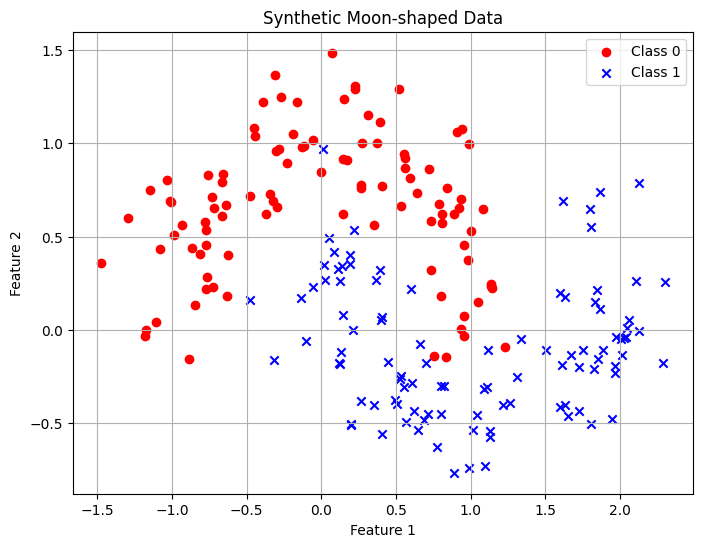

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Generate a synthetic dataset for classification
X, y = datasets.make_moons(n_samples=200, noise=0.2, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features (important for SVMs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data generated and split successfully.")
print(f"Training data shape: {X_train_scaled.shape}, Testing data shape: {X_test_scaled.shape}")

# Visualize the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', marker='o', label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', marker='x', label='Class 1')
plt.title('Synthetic Moon-shaped Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

Now, let's train an SVM classifier with an RBF (Radial Basis Function) kernel. The RBF kernel is a popular choice for non-linear decision boundaries.

In [2]:
# Initialize and train the SVM classifier with an RBF kernel
# C is the regularization parameter, gamma defines the influence of a single training example.
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_classifier.fit(X_train_scaled, y_train)

print("SVM classifier trained successfully.")

SVM classifier trained successfully.


Finally, let's evaluate the performance of our trained SVM model on the test set. We'll look at accuracy, a classification report (precision, recall, f1-score), and a confusion matrix.

Accuracy: 0.9833

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        32
           1       1.00      0.96      0.98        28

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


Confusion Matrix:
[[32  0]
 [ 1 27]]


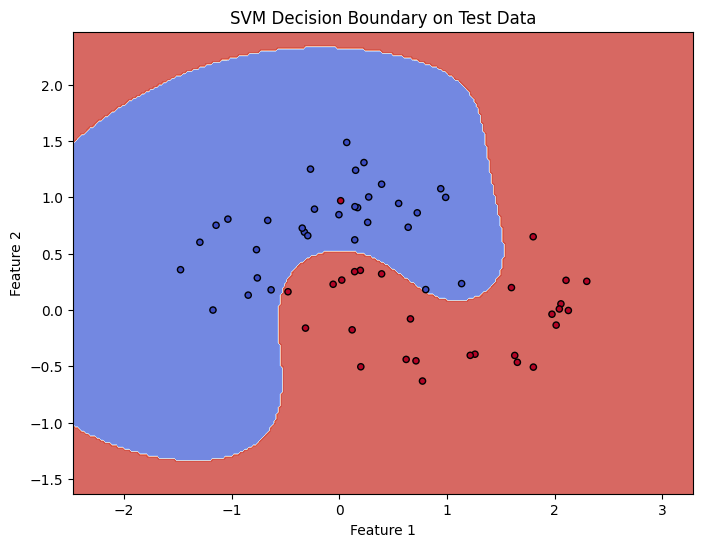

In [3]:
# Make predictions on the scaled test data
y_pred = svm_classifier.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(cm)

# Visualize the decision boundary
def plot_decision_boundary(X, y, classifier, scaler, title="Decision Boundary"):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Scale the mesh points
    if scaler is not None:
        Z = classifier.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
    else:
        Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title)
    plt.show()

plot_decision_boundary(X_test, y_test, svm_classifier, scaler, title='SVM Decision Boundary on Test Data')